In [1]:
from create_spectrum_SOAP import create_spectrum_soap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Stellar properties
logg= 4.44                                           # Logarithm of surface gravity [cm/s^2]
feh= 0.00                                           # Metallicity in dex
teff=5778                                           # Stellar effective temperature [K]
wave_min = 3800.0                                      # Minimum wavelength [Ã…]
wave_max = 7800.0                                      # Maximum wavelength [Ã…]
wave_range = (wave_min, wave_max)
R = 115000


In [ ]:

wave_conv, flux_conv = create_spectrum_soap(
    teff=teff,
    logg=logg,
    z=feh,
    wave_min=wave_min,
    wave_max=wave_max,
    wavelength_mode="vacuum",  # or "air"
    r=R,                  # or None
    normalize_max = True
)


In [ ]:

wave_orig, flux_orig = create_spectrum_soap(
    teff=teff,
    logg=logg,
    z=feh,
    wave_min=wave_min,
    wave_max=wave_max,
    wavelength_mode="vacuum",  # or "air"
    r=None,                  # or None
    normalize_max = True
)


In [ ]:
wave_bined_3 = wave_conv[::3]
flux_bined_3 = flux_conv[::3]

output_csv = 'wave_flux_conv.csv'
pd.DataFrame({'wave_val': wave_conv, 'flux_val': flux_conv}).to_csv(output_csv, index=False)
print(f'Saved: {output_csv}')


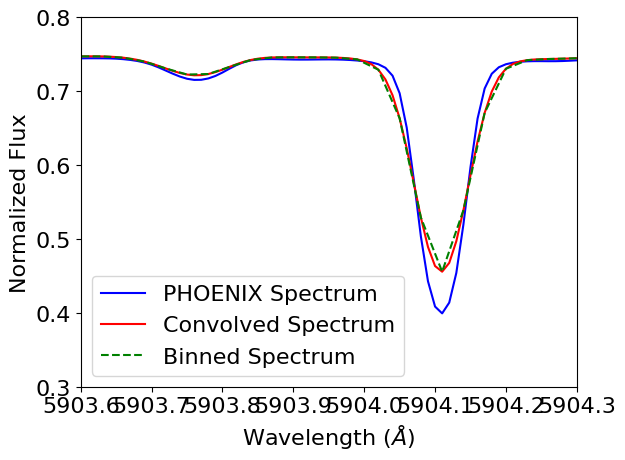

In [ ]:
plt.plot(wave_orig, flux_orig, 'b-', label='PHOENIX Spectrum')
plt.plot(wave_conv, flux_conv, 'r-', label='Convolved Spectrum')
plt.plot(wave_bined_3, flux_bined_3, 'g--', label='Binned Spectrum')
plt.xlim(5903.6, 5904.3)
plt.ylim(0.3,0.8)
plt.xlabel("Wavelength ("+r"$\AA$"+")")
plt.ylabel("Normalized Flux");
plt.legend()

In [ ]:
"""
ARVE CCF Example.
"""

#%%
### PACKAGES

import arve
from   glob              import glob
import matplotlib.pyplot as     plt
import numpy             as     np

#%%
### ARVE CCF

# Files
files = sorted(glob("wave_flux_conv.csv"))
Nfile = len(files)

# Times
time_val = np.arange(Nfile)

# Initiate ARVE object
example = arve.ARVE()

# Specify target and fetch parameters from SIMBAD
example.star.target = "Sun"
example.star.get_stellar_parameters()

# Or, specify stellar parameters manually
example.star.target = "Sun"
example.star.stellar_parameters = {
'sptype'  : 'G2',
'vrad_sys': 0.0,
'berv_max': 1.0,
'Teff'    : 5770,
'logg'    : 4.4,
'Fe_H'    : 0.0,
'M'       : 1.0,
'R'       : 1.0,
'vsini'   : 1.63,
'vmic'    : 0.85,
'vmac'    : 3.98
}